In [1]:
import pandas as pd

data = pd.read_csv('task/bonus_task.csv', index_col=0)
data.head()

,Title,Synopsis,Tag
0,I tre volti della paura,Note: this synopsis is for the orginal Italian...,"cult, horror, gothic, murder, atmospheric"
1,Dungeons & Dragons: The Book of Vile Darkness,"Two thousand years ago, Nhagruul the Foul, a s...",violence
2,The Shop Around the Corner,"Matuschek's, a gift store in Budapest, is the ...",romantic
3,Mr. Holland's Opus,"Glenn Holland, not a morning person by anyone'...","inspiring, romantic, stupid, feel-good"
4,Scarface,"In May 1980, a Cuban man named Tony Montana (A...","cruelty, murder, dramatic, cult, violence, atm..."


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14828 entries, 0 to 14827
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Title     14828 non-null  object
 1   Synopsis  14828 non-null  object
 2   Tag       14828 non-null  object
dtypes: object(3)
memory usage: 463.4+ KB


/var/folders/cc/jj0007pj3wz5pdbmw23n5d4w0000gn/T/ipykernel_45241/2801420291.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Tag', data=tag_df, palette='Blues_d')


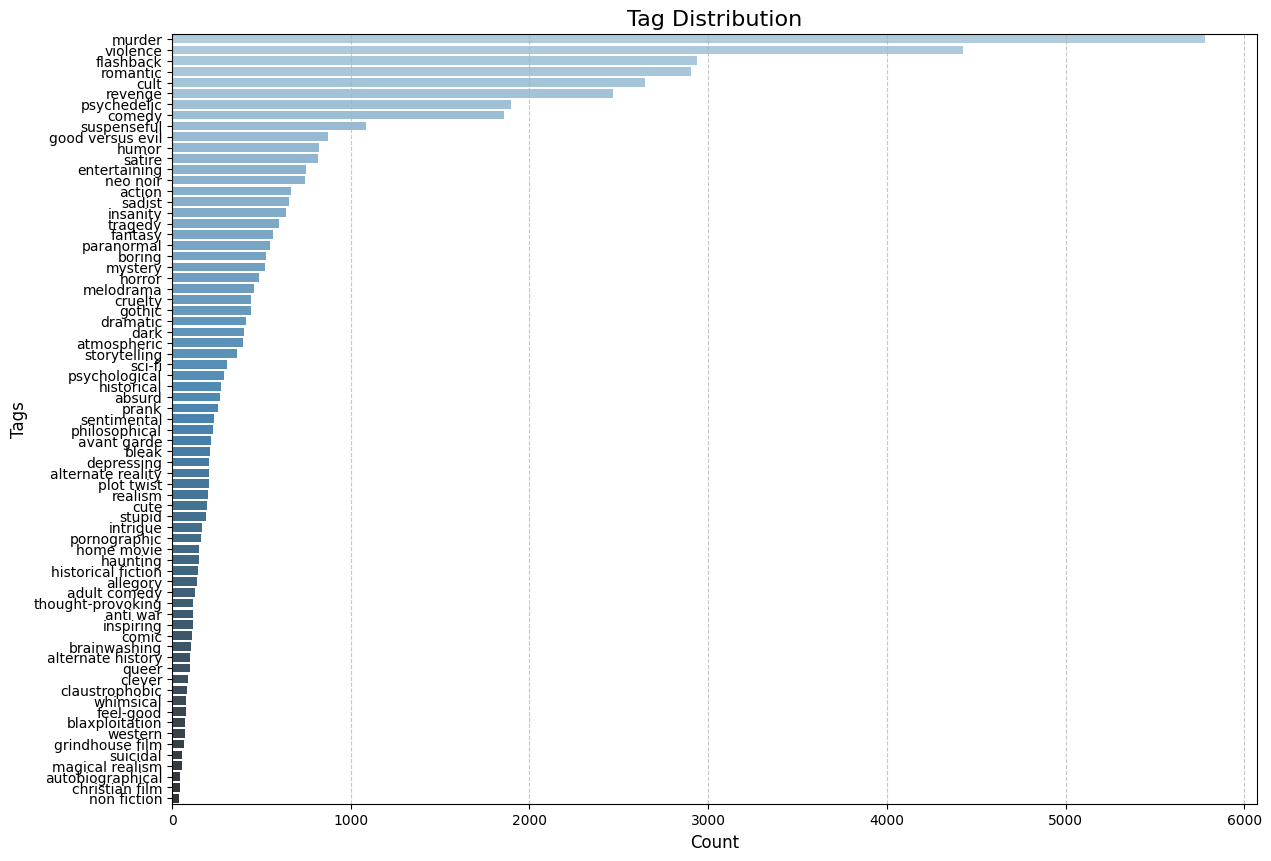

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

# Split the tags by comma and flatten the list
all_tags = data['Tag'].str.split(',').explode().str.strip()

# Count the occurrences of each tag
tag_counts = Counter(all_tags)

# Convert to DataFrame for better visualization
tag_df = pd.DataFrame(tag_counts.items(), columns=['Tag', 'Count']).sort_values(by='Count', ascending=False)

# Plot the distribution with Seaborn
plt.figure(figsize=(14, 10))
sns.barplot(x='Count', y='Tag', data=tag_df, palette='Blues_d')
plt.title('Tag Distribution', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Tags', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [4]:
from collections import Counter
import pandas as pd

# Flatten the list of tags
all_tags = data['Tag'].str.split(',').explode().str.strip()

# Count the occurrences of each tag
tag_counts = Counter(all_tags)

# Create a DataFrame for better visualization
tag_df = pd.DataFrame(tag_counts.items(), columns=['Tag', 'Count']).sort_values(by='Count', ascending=False)

# Display the most common tags
print("Most Common Tags:")
print(tag_df.head(10))

# Display the total number of unique "individual" tags:
print("\nTotal number of unique (individual) tags:", len(tag_df))

Most Common Tags:
                 Tag  Count
3             murder   5782
5           violence   4426
16         flashback   2937
6           romantic   2906
0               cult   2647
13           revenge   2468
21       psychedelic   1897
34            comedy   1859
18       suspenseful   1086
25  good versus evil    875

Total number of unique (individual) tags: 71


In [5]:
from collections import Counter
import pandas as pd

# Count the occurrences of each tag
tag_counts = Counter(data['Tag'])

# Create a DataFrame for better visualization
tag_df = pd.DataFrame(tag_counts.items(), columns=['Tag', 'Count']).sort_values(by='Count', ascending=False)

# Display the most common tags
print("Most Common Tags:")
print(tag_df.head(10))

# Display the total number of unique tags
print("\nTotal number of unique (grouped) tags:", len(tag_df))

Most Common Tags:
                  Tag  Count
12             murder   1004
2            romantic    731
1            violence    584
48        psychedelic    437
17          flashback    332
206  violence, murder    262
62            revenge    232
86               cult    226
41             comedy    157
29    revenge, murder    150

Total number of unique (grouped) tags: 5604


In [6]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

# Preprocessing data
def clean_text(text):
    """Enhanced text preprocessing"""
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove stopwords (keep important ones)
    stop_words = set(stopwords.words('english'))    
    important_words = {'not', 'no', 'never', 'against', 'between', 'through', 'during', 'before', 'after'}
    stop_words = stop_words - important_words
    text = ' '.join([word for word in text.split() if word not in stop_words])

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])
    
    return text
    
data['combined'] = data['Title'] + ' ' + data['Synopsis']
data['cleaned_text'] = data['combined'].apply(clean_text)

# Vectorize data
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    )
vectorizer.fit(data['cleaned_text'])
X = vectorizer.transform(data['cleaned_text'])

# MultiLabel Binarizer
data['Tag_transf'] = data['Tag'].str.split(',').apply(lambda x: [tag.strip() for tag in x])
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(data['Tag_transf'])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/catarina/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/catarina/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/catarina/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


murder              5782
violence            4426
flashback           2937
romantic            2906
cult                2647
                    ... 
magical realism       54
suicidal              54
autobiographical      44
christian film        42
non fiction           37
Length: 71, dtype: int64


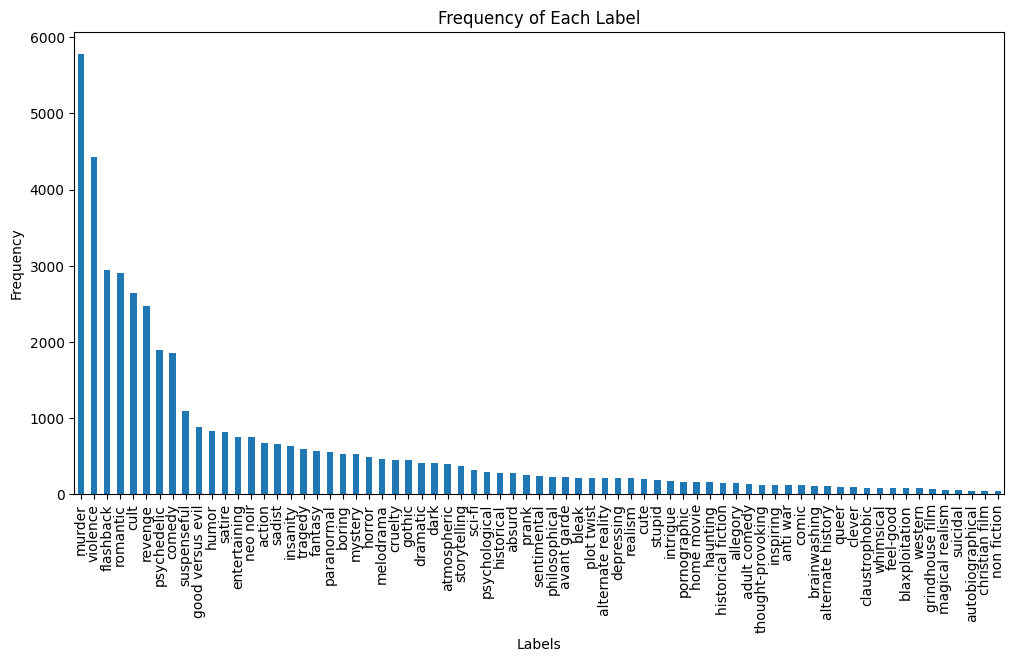

In [7]:
# Check the distribution of labels

import matplotlib.pyplot as plt
import pandas as pd

# Assuming `y` is your multi-label matrix (after MultiLabelBinarizer)
label_counts = pd.DataFrame(y, columns=mlb.classes_).sum().sort_values(ascending=False)

# Display label frequencies
print(label_counts)

# Plot it
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title('Frequency of Each Label')
plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.show()

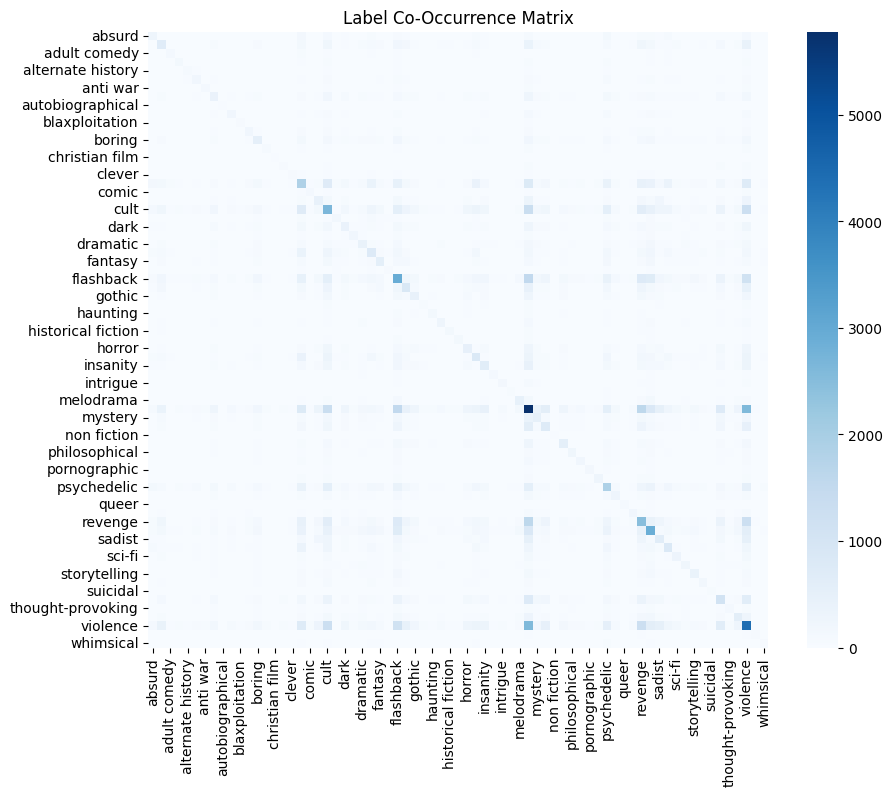

In [8]:
import seaborn as sns

# Create a co-occurrence matrix
co_occurrence = pd.DataFrame(y, columns=mlb.classes_).T.dot(pd.DataFrame(y, columns=mlb.classes_))
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=False, cmap='Blues')
plt.title('Label Co-Occurrence Matrix')
plt.show()

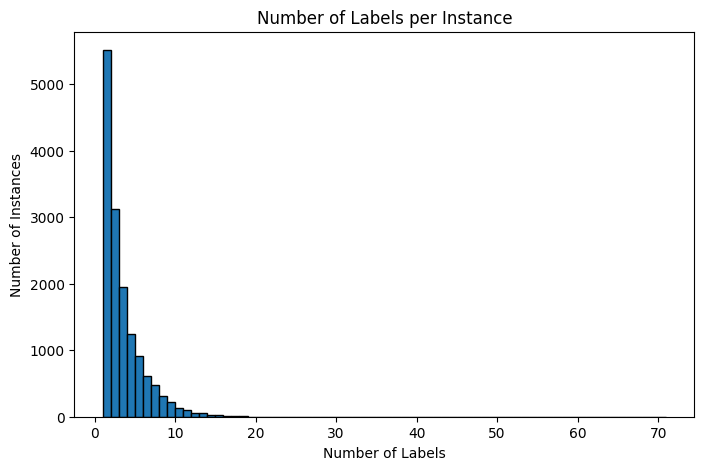

In [9]:
# Count the number of labels for each sample
num_labels_per_instance = (y > 0).sum(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(num_labels_per_instance, bins=range(1, y.shape[1] + 1), edgecolor='k')
plt.title('Number of Labels per Instance')
plt.xlabel('Number of Labels')
plt.ylabel('Number of Instances')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# Confirm the shape of your vectorized data
print(f"Shape of TF-IDF Matrix: {X.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply SMOTE to Each Label Separately
smote = SMOTE(random_state=42)

# Initialize variables
largest_resampled_size = 0
X_resampled = None
y_resampled = []

for i in range(y_train.shape[1]):  # Iterate over each label
    # Check if the target has more than one class
    unique_classes = np.unique(y_train[:, i])
    if len(unique_classes) > 1:  # Ensure there are at least two classes
        # Check if the minority class has enough samples for SMOTE
        unique, counts = np.unique(y_train[:, i], return_counts=True)
        minority_count = counts.min()
        
        if minority_count > smote.k_neighbors:  # Ensure sufficient samples for SMOTE
            X_resampled_label, y_resampled_label = smote.fit_resample(X_train, y_train[:, i])
            if X_resampled is None or X_resampled_label.shape[0] > largest_resampled_size:
                X_resampled = X_resampled_label  # Update with the largest resampled features
                largest_resampled_size = X_resampled_label.shape[0]
            y_resampled.append(y_resampled_label)  # Store resampled labels
        else:
            print(f"Skipping SMOTE for label {mlb.classes_[i]} due to insufficient samples.")
            y_resampled.append(None)  # Placeholder for later resizing
    else:
        print(f"Skipping SMOTE for label {mlb.classes_[i]} because it has only one class.")
        y_resampled.append(None)  # Placeholder for later resizing

# Resize all labels to match the largest resampled dataset size
for i in range(len(y_resampled)):
    if y_resampled[i] is None:
        y_resampled[i] = np.resize(y_train[:, i], largest_resampled_size)  # Resize to match largest size
    elif y_resampled[i].shape[0] < largest_resampled_size:
        y_resampled[i] = np.resize(y_resampled[i], largest_resampled_size)  # Resize to match largest size

# Combine resampled labels into a single matrix
y_resampled = np.column_stack(y_resampled)

print("\nResampled Feature Matrix Shape:", X_resampled.shape)
print("Resampled Label Matrix Shape:", y_resampled.shape)

Shape of TF-IDF Matrix: (14828, 2000)

Resampled Feature Matrix Shape: (20706, 2000)
Resampled Label Matrix Shape: (20706, 71)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
model.fit(X_resampled, y_resampled)

# Predict on the Test Set
y_pred = model.predict(X_test)

# Evaluate the Model
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))




Classification Report:
                    precision    recall  f1-score   support

            absurd       0.00      0.00      0.00        83
            action       0.38      0.04      0.07       217
      adult comedy       0.00      0.00      0.00        41
          allegory       0.50      0.02      0.05        41
 alternate history       0.00      0.00      0.00        24
 alternate reality       0.00      0.00      0.00        58
          anti war       1.00      0.03      0.05        36
       atmospheric       0.00      0.00      0.00       129
  autobiographical       0.00      0.00      0.00        12
       avant garde       0.33      0.01      0.03        71
    blaxploitation       1.00      0.04      0.07        28
             bleak       0.00      0.00      0.00        53
            boring       0.00      0.00      0.00       164
      brainwashing       0.00      0.00      0.00        31
    christian film       0.00      0.00      0.00        15
    claustropho

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report

X_train_tensor = torch.tensor(X_resampled.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_resampled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                          batch_size=32, 
                          shuffle=True, 
                          pin_memory=True, 
                          num_workers=2)

test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), 
                         batch_size=32, 
                         shuffle=False, 
                         pin_memory=True, 
                         num_workers=2)


# Model Definition
class MultiLabelNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MultiLabelNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Instantiate the model
model = MultiLabelNN(input_dim=2000, output_dim=len(mlb.classes_))
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# Training Loop
print("Starting training...")
epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")


# Evaluation Loop
print("Evaluating the model...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        predictions = (outputs > 0.5).int()
        all_preds.append(predictions)
        all_labels.append(y_batch)

# Concatenate all predictions and labels
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Classification Report
print("Generating classification report...")
print(classification_report(all_labels, all_preds, target_names=mlb.classes_))

Starting training...


/Users/catarina/Desktop/DataScience/DataScienceProjects/Enhesa_task/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [1/100], Loss: 0.1997
Epoch [2/100], Loss: 0.1718
Epoch [3/100], Loss: 0.1689
Epoch [4/100], Loss: 0.1660
Epoch [5/100], Loss: 0.1641
Epoch [6/100], Loss: 0.1617
Epoch [7/100], Loss: 0.1592
Epoch [8/100], Loss: 0.1573
Epoch [9/100], Loss: 0.1552
Epoch [10/100], Loss: 0.1531
Epoch [11/100], Loss: 0.1515
Epoch [12/100], Loss: 0.1510
Epoch [13/100], Loss: 0.1477
Epoch [14/100], Loss: 0.1454
Epoch [15/100], Loss: 0.1435
Epoch [16/100], Loss: 0.1414
Epoch [17/100], Loss: 0.1392
Epoch [18/100], Loss: 0.1382
Epoch [19/100], Loss: 0.1365
Epoch [20/100], Loss: 0.1351
Epoch [21/100], Loss: 0.1334
Epoch [22/100], Loss: 0.1320
Epoch [23/100], Loss: 0.1302
Epoch [24/100], Loss: 0.1292
Epoch [25/100], Loss: 0.1284
Epoch [26/100], Loss: 0.1293
Epoch [27/100], Loss: 0.1267
Epoch [28/100], Loss: 0.1255
Epoch [29/100], Loss: 0.1251
Epoch [30/100], Loss: 0.1241
Epoch [31/100], Loss: 0.1231
Epoch [32/100], Loss: 0.1226
Epoch [33/100], Loss: 0.1223
